# Task 3 — CycleGAN: Photo ↔ Monet Style Transfer

**DATA266 Lab 1 · `task3_gan/shreya_akotiya/`**

Unpaired image-to-image translation using Cycle-Consistent Adversarial Networks.

Architecture: **UNet generator** (vs zoheb's ResNet) at **128px** resolution.

---

## Contents
1. Bootstrap & Config
2. Data Loading
3. Model Architecture (UNet Generator, PatchGAN Discriminator)
4. Loss Functions & Training
5. Evaluation Metrics
6. Kaggle Submission
7. Reproducibility Manifest

## Step 0 — Bootstrap (Colab / Local)

In [ ]:
# ============================================================
# BOOTSTRAP — edit GITHUB_REPO if running on Colab from GitHub
# ============================================================
GITHUB_REPO = ""  # e.g. "https://github.com/yourteam/data266-lab1.git"

import sys, os, subprocess
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # Install missing packages
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "kaggle", "pytorch-fid", "lpips", "clean-fid"], check=True)

    # Mount Google Drive
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)

    # Set up paths
    DRIVE_ROOT = "/content/drive/MyDrive/DATA266_Lab1"
    os.makedirs(DRIVE_ROOT, exist_ok=True)

    if GITHUB_REPO:
        REPO_DIR = f"{DRIVE_ROOT}/data266-lab1"
        if not os.path.exists(REPO_DIR):
            subprocess.run(["git", "clone", GITHUB_REPO, REPO_DIR], check=True)
        os.chdir(REPO_DIR)
    else:
        REPO_DIR = f"{DRIVE_ROOT}/"
        os.chdir(REPO_DIR)

    os.environ["LAB1_ROOT"] = REPO_DIR
    os.environ["LAB1_DATA"] = "/content/lab1_data"  # Fast local disk for images

    print(f"Colab bootstrap complete. Working dir: {os.getcwd()}")
else:
    print(f"Running locally. CWD: {os.getcwd()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Colab bootstrap complete. Working dir: /content/drive/MyDrive/DATA266_Lab1


## Step 1 — Imports & Config

In [ ]:
import os
import sys
import time
import json
import hashlib
import random
import itertools
from pathlib import Path
from datetime import datetime
from collections import deque

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import make_grid, save_image

print(f"PyTorch {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"MPS available: {torch.backends.mps.is_available()}")

PyTorch 2.11.0+cu130
CUDA available: True
MPS available: False


In [ ]:
# Find project root
def find_project_root():
    if os.environ.get("LAB1_ROOT"):
        return Path(os.environ["LAB1_ROOT"])
    p = Path.cwd()
    while p != p.parent:
        if (p / "task3_gan").exists():
            return p
        p = p.parent
    raise RuntimeError("Cannot find project root")

PROJECT_ROOT = find_project_root()
MEMBER = "shreya_akotiya"
MEMBER_DIR = PROJECT_ROOT / "task3_gan" / MEMBER
CONFIG_PATH = os.environ.get("LAB1_CONFIG", MEMBER_DIR / "config.yaml")

with open(CONFIG_PATH) as f:
    CFG = yaml.safe_load(f)

print(f"Project root: {PROJECT_ROOT}")
print(f"Config: {CONFIG_PATH}")
print(f"Run tag: {CFG['run']['tag']}")

Project root: /content/drive/MyDrive/DATA266_Lab1
Config: /content/drive/MyDrive/DATA266_Lab1/task3_gan/shreya_akotiya/config.yaml
Run tag: t3_shreya_unet_128


In [ ]:
# Device selection
def get_device(cfg_device: str) -> torch.device:
    if cfg_device == "auto":
        if torch.cuda.is_available():
            return torch.device("cuda")
        elif torch.backends.mps.is_available():
            return torch.device("mps")
        return torch.device("cpu")
    return torch.device(cfg_device)

DEVICE = get_device(CFG["run"]["device"])
print(f"Device: {DEVICE}")

# Seed everything
SEED = CFG["run"]["seed"]
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Device: cuda


In [ ]:
# Paths
DATA_ROOT =  PROJECT_ROOT / "task3_gan" / "data"
if "task3" not in str(DATA_ROOT):
    DATA_ROOT = DATA_ROOT / "task3_gan" / "data"

DOMAIN_A_DIR = DATA_ROOT / "photo_jpg"    # Photos
DOMAIN_B_DIR = DATA_ROOT / "monet_jpg"    # Monet paintings

OUTPUT_DIR = PROJECT_ROOT / CFG["paths"]["output_dir"]
CKPT_DIR = PROJECT_ROOT / CFG["paths"]["checkpoint_dir"]
LOG_DIR = PROJECT_ROOT / CFG["paths"]["log_dir"]

for d in [OUTPUT_DIR, CKPT_DIR, LOG_DIR, OUTPUT_DIR / "plots", OUTPUT_DIR / "samples",
          OUTPUT_DIR / "pred_A2B", OUTPUT_DIR / "pred_B2A"]:
    d.mkdir(parents=True, exist_ok=True)

RUN_TAG = f"{CFG['run']['tag']}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
LOG_FILE = LOG_DIR / f"{RUN_TAG}.log"
print(f"Run tag: {RUN_TAG}")
print(f"Log file: {LOG_FILE}")
print(f"DOMAIN_A_DIR file: {DOMAIN_A_DIR}")
print(f"DOMAIN_B_DIR file: {DOMAIN_B_DIR}")

Run tag: t3_shreya_unet_128_20261002_023102
Log file: /content/drive/MyDrive/DATA266_Lab1/reproducibility/raw_logs/shreya_akotiya/task3_gan/t3_shreya_unet_128_20261002_023102.log
DOMAIN_A_DIR file: /content/drive/MyDrive/DATA266_Lab1/task3_gan/data/photo_jpg
DOMAIN_B_DIR file: /content/drive/MyDrive/DATA266_Lab1/task3_gan/data/monet_jpg


In [ ]:
# ============================================
# OVERRIDE: UNet 256px for better FID
# ============================================
CFG["data"]["image_size"] = 256
CFG["data"]["load_size"] = 286
CFG["model"]["gen_down_blocks"] = 8
CFG["model"]["disc_layers"] = 3
CFG["train"]["epochs"] = 80
CFG["train"]["epochs_decay"] = 20
CFG["run"]["tag"] = "t3_shreya_unet_256"

# Update globals
IMG_SIZE = 256
LOAD_SIZE = 286

# Recreate transforms with new size
train_transform = transforms.Compose([
    transforms.Resize(LOAD_SIZE, transforms.InterpolationMode.BICUBIC),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), transforms.InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

print(f"Updated: {IMG_SIZE}px, {CFG['train']['epochs']} epochs, tag={CFG['run']['tag']}")


Updated: 256px, 80 epochs, tag=t3_shreya_unet_256


## Step 2 — Data Loading

In [ ]:
# Check data exists
if not DOMAIN_A_DIR.exists() or not DOMAIN_B_DIR.exists():
    print(f"Data not found. Run: python task3_gan/shreya_akotiya/src/fetch_data.py")
    print(f"Expected: {DOMAIN_A_DIR} and {DOMAIN_B_DIR}")
else:
    n_photos = len(list(DOMAIN_A_DIR.glob("*.jpg")))
    n_monet = len(list(DOMAIN_B_DIR.glob("*.jpg")))
    print(f"Photos (Domain A): {n_photos:,}")
    print(f"Monet (Domain B): {n_monet:,}")

Photos (Domain A): 7,038
Monet (Domain B): 300


In [ ]:
class ImageDataset(Dataset):
    """Unpaired image dataset for CycleGAN."""

    def __init__(self, root_a: Path, root_b: Path, transform=None, unaligned=True):
        self.files_a = sorted(root_a.glob("*.jpg"))
        self.files_b = sorted(root_b.glob("*.jpg"))
        self.transform = transform
        self.unaligned = unaligned

    def __len__(self):
        return max(len(self.files_a), len(self.files_b))

    def __getitem__(self, idx):
        img_a = Image.open(self.files_a[idx % len(self.files_a)]).convert("RGB")

        if self.unaligned:
            img_b = Image.open(self.files_b[random.randint(0, len(self.files_b)-1)]).convert("RGB")
        else:
            img_b = Image.open(self.files_b[idx % len(self.files_b)]).convert("RGB")

        if self.transform:
            img_a = self.transform(img_a)
            img_b = self.transform(img_b)

        return {"A": img_a, "B": img_b}

In [ ]:
# Transforms
IMG_SIZE = CFG["data"]["image_size"]
LOAD_SIZE = CFG["data"]["load_size"]

train_transform = transforms.Compose([
    transforms.Resize(LOAD_SIZE, transforms.InterpolationMode.BICUBIC),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip() if CFG["data"]["random_flip"] else transforms.Lambda(lambda x: x),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # [-1, 1]
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), transforms.InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Load size: {LOAD_SIZE}")

Image size: 256x256
Load size: 286


In [ ]:
# Create dataset and dataloader
train_dataset = ImageDataset(DOMAIN_A_DIR, DOMAIN_B_DIR, transform=train_transform)
train_loader = DataLoader(
    train_dataset,
    batch_size=CFG["train"]["batch_size"],
    shuffle=True,
    num_workers=CFG["data"]["num_workers"],
    pin_memory=True,
    drop_last=True
)

print(f"Training samples per epoch: {len(train_dataset):,}")
print(f"Batches per epoch: {len(train_loader):,}")

Training samples per epoch: 7,038
Batches per epoch: 7,038


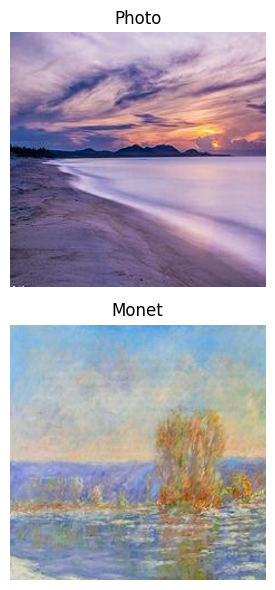

In [ ]:
# Visualize samples
sample_batch = next(iter(train_loader))
batch_size = sample_batch["A"].shape[0]
n_show = min(4, batch_size)

fig, axes = plt.subplots(2, max(n_show, 1), figsize=(3*max(n_show,1), 6))
if n_show == 1:
    axes = axes.reshape(2, 1)

for i in range(n_show):
    # Photo (Domain A)
    img_a = sample_batch["A"][i].numpy().transpose(1, 2, 0) * 0.5 + 0.5
    axes[0, i].imshow(np.clip(img_a, 0, 1))
    axes[0, i].set_title("Photo" if i == 0 else "")
    axes[0, i].axis("off")
    # Monet (Domain B)
    img_b = sample_batch["B"][i].numpy().transpose(1, 2, 0) * 0.5 + 0.5
    axes[1, i].imshow(np.clip(img_b, 0, 1))
    axes[1, i].set_title("Monet" if i == 0 else "")
    axes[1, i].axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plots" / "data_samples.png", dpi=150)
plt.show()

## Step 3 — Model Architecture

**UNet Generator** with skip connections (different from zoheb's ResNet).

**PatchGAN Discriminator** with 4 layers (zoheb uses 3).

In [ ]:
def weights_init(m):
    """Initialize weights with normal distribution."""
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
        if hasattr(m, "bias") and m.bias is not None:
            nn.init.constant_(m.bias.data, 0.0)
    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0.0)
    elif classname.find("InstanceNorm") != -1:
        if m.weight is not None:
            nn.init.normal_(m.weight.data, 1.0, 0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias.data, 0.0)

In [ ]:
class UNetDown(nn.Module):
    """UNet encoder block: Conv -> Norm -> LeakyReLU."""

    def __init__(self, in_ch, out_ch, normalize=True, dropout=0.0):
        super().__init__()
        layers = [nn.Conv2d(in_ch, out_ch, 4, stride=2, padding=1, bias=False)]
        if normalize:
            layers.append(nn.InstanceNorm2d(out_ch))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


class UNetUp(nn.Module):
    """UNet decoder block: ConvTranspose -> Norm -> ReLU."""

    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        layers = [
            nn.ConvTranspose2d(in_ch, out_ch, 4, stride=2, padding=1, bias=False),
            nn.InstanceNorm2d(out_ch),
            nn.ReLU(inplace=True)
        ]
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)

    def forward(self, x, skip):
        x = self.model(x)
        return torch.cat([x, skip], dim=1)

In [ ]:
class UNetGenerator(nn.Module):
    """
    UNet-based Generator with skip connections.

    For 128x128 input with 7 down blocks:
    128 -> 64 -> 32 -> 16 -> 8 -> 4 -> 2 -> 1
    """

    def __init__(self, in_ch=3, out_ch=3, num_downs=7, ngf=64, use_dropout=True):
        super().__init__()

        # Encoder
        self.down1 = UNetDown(in_ch, ngf, normalize=False)         # 128 -> 64
        self.down2 = UNetDown(ngf, ngf * 2)                        # 64 -> 32
        self.down3 = UNetDown(ngf * 2, ngf * 4)                    # 32 -> 16
        self.down4 = UNetDown(ngf * 4, ngf * 8)                    # 16 -> 8
        self.down5 = UNetDown(ngf * 8, ngf * 8)                    # 8 -> 4
        self.down6 = UNetDown(ngf * 8, ngf * 8)                    # 4 -> 2
        self.down7 = UNetDown(ngf * 8, ngf * 8, normalize=False)   # 2 -> 1

        # Decoder with skip connections
        dropout = 0.5 if use_dropout else 0.0
        self.up1 = UNetUp(ngf * 8, ngf * 8, dropout=dropout)       # 1 -> 2
        self.up2 = UNetUp(ngf * 16, ngf * 8, dropout=dropout)      # 2 -> 4
        self.up3 = UNetUp(ngf * 16, ngf * 8, dropout=dropout)      # 4 -> 8
        self.up4 = UNetUp(ngf * 16, ngf * 4)                       # 8 -> 16
        self.up5 = UNetUp(ngf * 8, ngf * 2)                        # 16 -> 32
        self.up6 = UNetUp(ngf * 4, ngf)                            # 32 -> 64

        # Final layer
        self.final = nn.Sequential(
            nn.ConvTranspose2d(ngf * 2, out_ch, 4, stride=2, padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        # Encoder
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        d5 = self.down5(d4)
        d6 = self.down6(d5)
        d7 = self.down7(d6)

        # Decoder with skip connections
        u1 = self.up1(d7, d6)
        u2 = self.up2(u1, d5)
        u3 = self.up3(u2, d4)
        u4 = self.up4(u3, d3)
        u5 = self.up5(u4, d2)
        u6 = self.up6(u5, d1)

        return self.final(u6)

In [ ]:
class PatchGANDiscriminator(nn.Module):
    """
    PatchGAN discriminator.

    Outputs NxN grid of predictions (real/fake for each patch).
    4 layers gives ~34x34 receptive field.
    """

    def __init__(self, in_ch=3, ndf=64, n_layers=4):
        super().__init__()

        layers = [nn.Conv2d(in_ch, ndf, 4, stride=2, padding=1),
                  nn.LeakyReLU(0.2, inplace=True)]

        nf_mult = 1
        for n in range(1, n_layers):
            nf_mult_prev = nf_mult
            nf_mult = min(2 ** n, 8)
            layers += [
                nn.Conv2d(ndf * nf_mult_prev, ndf * nf_mult, 4, stride=2, padding=1, bias=False),
                nn.InstanceNorm2d(ndf * nf_mult),
                nn.LeakyReLU(0.2, inplace=True)
            ]

        # Final layer - single channel output
        layers += [nn.Conv2d(ndf * nf_mult, 1, 4, stride=1, padding=1)]

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

In [ ]:
# Create models
ngf = CFG["model"]["gen_filters"]
ndf = CFG["model"]["disc_filters"]
n_disc_layers = CFG["model"]["disc_layers"]
use_dropout = CFG["model"]["gen_use_dropout"]

G_AB = UNetGenerator(3, 3, num_downs=7, ngf=ngf, use_dropout=use_dropout).to(DEVICE)  # Photo -> Monet
G_BA = UNetGenerator(3, 3, num_downs=7, ngf=ngf, use_dropout=use_dropout).to(DEVICE)  # Monet -> Photo
D_A = PatchGANDiscriminator(3, ndf, n_disc_layers).to(DEVICE)  # Discriminate photos
D_B = PatchGANDiscriminator(3, ndf, n_disc_layers).to(DEVICE)  # Discriminate Monet

# Initialize weights
G_AB.apply(weights_init)
G_BA.apply(weights_init)
D_A.apply(weights_init)
D_B.apply(weights_init)

# Count parameters
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"G_AB (Photo->Monet): {count_params(G_AB):,} params")
print(f"G_BA (Monet->Photo): {count_params(G_BA):,} params")
print(f"D_A (Photo disc):    {count_params(D_A):,} params")
print(f"D_B (Monet disc):    {count_params(D_B):,} params")
print(f"Total:               {count_params(G_AB) + count_params(G_BA) + count_params(D_A) + count_params(D_B):,} params")

G_AB (Photo->Monet): 41,821,187 params
G_BA (Monet->Photo): 41,821,187 params
D_A (Photo disc):    662,593 params
D_B (Monet disc):    662,593 params
Total:               84,967,560 params


In [ ]:
# Test forward pass
with torch.no_grad():
    test_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    test_out_g = G_AB(test_input)
    test_out_d = D_B(test_input)
    print(f"Generator input:  {test_input.shape}")
    print(f"Generator output: {test_out_g.shape}")
    print(f"Discriminator output: {test_out_d.shape}")

Generator input:  torch.Size([1, 3, 256, 256])
Generator output: torch.Size([1, 3, 256, 256])
Discriminator output: torch.Size([1, 1, 31, 31])


## Step 4 — Loss Functions & Training

In [ ]:
class ReplayBuffer:
    """Image buffer to store previously generated images for discriminator training."""

    def __init__(self, max_size=50):
        self.max_size = max_size
        self.data = []

    def push_and_pop(self, data):
        result = []
        for element in data:
            element = element.unsqueeze(0)
            if len(self.data) < self.max_size:
                self.data.append(element)
                result.append(element)
            else:
                if random.uniform(0, 1) > 0.5:
                    idx = random.randint(0, self.max_size - 1)
                    result.append(self.data[idx].clone())
                    self.data[idx] = element
                else:
                    result.append(element)
        return torch.cat(result, dim=0)

In [ ]:
# Loss functions
gan_mode = CFG["loss"]["gan_mode"]
if gan_mode == "lsgan":
    criterion_GAN = nn.MSELoss()
else:
    criterion_GAN = nn.BCEWithLogitsLoss()

criterion_cycle = nn.L1Loss()
criterion_identity = nn.L1Loss()

# Loss weights
lambda_cycle_A = CFG["loss"]["lambda_cycle_a"]
lambda_cycle_B = CFG["loss"]["lambda_cycle_b"]
lambda_identity = CFG["loss"]["lambda_identity"]

print(f"GAN mode: {gan_mode}")
print(f"Lambda cycle A: {lambda_cycle_A}")
print(f"Lambda cycle B: {lambda_cycle_B}")
print(f"Lambda identity: {lambda_identity}")

GAN mode: lsgan
Lambda cycle A: 10.0
Lambda cycle B: 10.0
Lambda identity: 0.5


In [ ]:
# Optimizers
lr = CFG["train"]["lr"]
betas = tuple(CFG["train"]["betas"])

opt_G = torch.optim.Adam(
    itertools.chain(G_AB.parameters(), G_BA.parameters()),
    lr=lr, betas=betas
)
opt_D_A = torch.optim.Adam(D_A.parameters(), lr=lr, betas=betas)
opt_D_B = torch.optim.Adam(D_B.parameters(), lr=lr, betas=betas)

# Learning rate schedulers (linear decay)
n_epochs = CFG["train"]["epochs"]
n_epochs_decay = CFG["train"]["epochs_decay"]

def lr_lambda(epoch):
    return 1.0 - max(0, epoch - (n_epochs - n_epochs_decay)) / float(n_epochs_decay + 1)

scheduler_G = torch.optim.lr_scheduler.LambdaLR(opt_G, lr_lambda)
scheduler_D_A = torch.optim.lr_scheduler.LambdaLR(opt_D_A, lr_lambda)
scheduler_D_B = torch.optim.lr_scheduler.LambdaLR(opt_D_B, lr_lambda)

print(f"Learning rate: {lr}")
print(f"Epochs: {n_epochs}, decay starts at: {n_epochs - n_epochs_decay}")

Learning rate: 0.0002
Epochs: 80, decay starts at: 60


In [ ]:
# Replay buffers
buffer_size = CFG["loss"]["image_pool_size"]
fake_A_buffer = ReplayBuffer(buffer_size)
fake_B_buffer = ReplayBuffer(buffer_size)

print(f"Replay buffer size: {buffer_size}")

Replay buffer size: 50


In [ ]:
# Logging
log_file = open(LOG_FILE, "w")

def log(msg):
    print(msg)
    log_file.write(msg + "\n")
    log_file.flush()

log(f"Run: {RUN_TAG}")
log(f"Config: {CONFIG_PATH}")
log(f"Device: {DEVICE}")
log(f"Image size: {IMG_SIZE}")
log(f"Epochs: {n_epochs}")
log("")

Run: t3_shreya_unet_128_20261002_023102
Config: /content/drive/MyDrive/DATA266_Lab1/task3_gan/shreya_akotiya/config.yaml
Device: cuda
Image size: 256
Epochs: 80



In [ ]:
def save_sample_images(epoch, real_A, real_B, fake_A, fake_B, rec_A, rec_B):
    """Save sample images during training."""
    def denorm(x):
        return (x * 0.5 + 0.5).clamp(0, 1)

    # Arrange: real_A, fake_B (A->B), rec_A, real_B, fake_A (B->A), rec_B
    images = torch.cat([
        denorm(real_A[:4]),
        denorm(fake_B[:4]),
        denorm(rec_A[:4]),
        denorm(real_B[:4]),
        denorm(fake_A[:4]),
        denorm(rec_B[:4])
    ], dim=0)

    grid = make_grid(images, nrow=4, padding=2, normalize=False)
    save_image(grid, OUTPUT_DIR / "samples" / f"epoch_{epoch:03d}.png")

In [ ]:
# Training history
history = {
    "epoch": [], "step": [],
    "loss_G": [], "loss_D_A": [], "loss_D_B": [],
    "loss_cycle_A": [], "loss_cycle_B": [],
    "loss_identity_A": [], "loss_identity_B": [],
    "loss_GAN_AB": [], "loss_GAN_BA": [],
    "lr": []
}

In [ ]:
# Training loop
log_interval = CFG["train"]["log_interval_steps"]
sample_interval = CFG["train"]["sample_interval_steps"]
ckpt_interval = CFG["train"]["checkpoint_interval_epochs"]

global_step = 0
t_start = time.time()

log(f"Starting training: {n_epochs} epochs, {len(train_loader)} batches/epoch")
log("="*60)

for epoch in range(1, n_epochs + 1):
    epoch_start = time.time()
    epoch_losses = {k: 0.0 for k in ["G", "D_A", "D_B", "cycle_A", "cycle_B", "ident_A", "ident_B", "GAN_AB", "GAN_BA"]}

    for i, batch in enumerate(train_loader):
        real_A = batch["A"].to(DEVICE)
        real_B = batch["B"].to(DEVICE)

        # Target tensors for LSGAN
        valid = torch.ones_like(D_A(real_A)).to(DEVICE)
        fake = torch.zeros_like(D_A(real_A)).to(DEVICE)

        # ==================== Train Generators ====================
        opt_G.zero_grad()

        # Identity loss
        if lambda_identity > 0:
            same_B = G_AB(real_B)
            loss_identity_B = criterion_identity(same_B, real_B) * lambda_cycle_B * lambda_identity
            same_A = G_BA(real_A)
            loss_identity_A = criterion_identity(same_A, real_A) * lambda_cycle_A * lambda_identity
        else:
            loss_identity_A = loss_identity_B = 0

        # GAN loss
        fake_B = G_AB(real_A)
        pred_fake_B = D_B(fake_B)
        loss_GAN_AB = criterion_GAN(pred_fake_B, torch.ones_like(pred_fake_B))

        fake_A = G_BA(real_B)
        pred_fake_A = D_A(fake_A)
        loss_GAN_BA = criterion_GAN(pred_fake_A, torch.ones_like(pred_fake_A))

        # Cycle loss
        rec_A = G_BA(fake_B)
        loss_cycle_A = criterion_cycle(rec_A, real_A) * lambda_cycle_A

        rec_B = G_AB(fake_A)
        loss_cycle_B = criterion_cycle(rec_B, real_B) * lambda_cycle_B

        # Total generator loss
        loss_G = loss_GAN_AB + loss_GAN_BA + loss_cycle_A + loss_cycle_B
        if lambda_identity > 0:
            loss_G += loss_identity_A + loss_identity_B

        loss_G.backward()
        opt_G.step()

        # ==================== Train Discriminator A ====================
        opt_D_A.zero_grad()

        pred_real_A = D_A(real_A)
        loss_D_real_A = criterion_GAN(pred_real_A, torch.ones_like(pred_real_A))

        fake_A_buffered = fake_A_buffer.push_and_pop(fake_A.detach())
        pred_fake_A = D_A(fake_A_buffered)
        loss_D_fake_A = criterion_GAN(pred_fake_A, torch.zeros_like(pred_fake_A))

        loss_D_A = (loss_D_real_A + loss_D_fake_A) * 0.5
        loss_D_A.backward()
        opt_D_A.step()

        # ==================== Train Discriminator B ====================
        opt_D_B.zero_grad()

        pred_real_B = D_B(real_B)
        loss_D_real_B = criterion_GAN(pred_real_B, torch.ones_like(pred_real_B))

        fake_B_buffered = fake_B_buffer.push_and_pop(fake_B.detach())
        pred_fake_B = D_B(fake_B_buffered)
        loss_D_fake_B = criterion_GAN(pred_fake_B, torch.zeros_like(pred_fake_B))

        loss_D_B = (loss_D_real_B + loss_D_fake_B) * 0.5
        loss_D_B.backward()
        opt_D_B.step()

        # Accumulate losses
        epoch_losses["G"] += loss_G.item()
        epoch_losses["D_A"] += loss_D_A.item()
        epoch_losses["D_B"] += loss_D_B.item()
        epoch_losses["cycle_A"] += loss_cycle_A.item()
        epoch_losses["cycle_B"] += loss_cycle_B.item()
        epoch_losses["GAN_AB"] += loss_GAN_AB.item()
        epoch_losses["GAN_BA"] += loss_GAN_BA.item()
        if lambda_identity > 0:
            epoch_losses["ident_A"] += loss_identity_A.item()
            epoch_losses["ident_B"] += loss_identity_B.item()

        global_step += 1

        # Log progress
        if global_step % log_interval == 0:
            log(f"Epoch {epoch}/{n_epochs} | Step {global_step} | "
                f"G: {loss_G.item():.4f} | D_A: {loss_D_A.item():.4f} | D_B: {loss_D_B.item():.4f} | "
                f"Cycle: {loss_cycle_A.item() + loss_cycle_B.item():.4f}")

        # Save sample images
        if global_step % sample_interval == 0:
            save_sample_images(epoch, real_A, real_B, fake_A, fake_B, rec_A, rec_B)

    # End of epoch
    n_batches = len(train_loader)
    for k in epoch_losses:
        epoch_losses[k] /= n_batches

    # Record history
    history["epoch"].append(epoch)
    history["step"].append(global_step)
    history["loss_G"].append(epoch_losses["G"])
    history["loss_D_A"].append(epoch_losses["D_A"])
    history["loss_D_B"].append(epoch_losses["D_B"])
    history["loss_cycle_A"].append(epoch_losses["cycle_A"])
    history["loss_cycle_B"].append(epoch_losses["cycle_B"])
    history["loss_identity_A"].append(epoch_losses["ident_A"])
    history["loss_identity_B"].append(epoch_losses["ident_B"])
    history["loss_GAN_AB"].append(epoch_losses["GAN_AB"])
    history["loss_GAN_BA"].append(epoch_losses["GAN_BA"])
    history["lr"].append(scheduler_G.get_last_lr()[0])

    epoch_time = time.time() - epoch_start
    log(f"Epoch {epoch}/{n_epochs} complete | Time: {epoch_time:.0f}s | "
        f"Avg G: {epoch_losses['G']:.4f} | Avg D: {(epoch_losses['D_A']+epoch_losses['D_B'])/2:.4f}")

    # Step schedulers
    scheduler_G.step()
    scheduler_D_A.step()
    scheduler_D_B.step()

    # Save checkpoint
    if epoch % ckpt_interval == 0 or epoch == n_epochs:
        ckpt_path = CKPT_DIR / f"{RUN_TAG}_epoch{epoch:03d}.pt"
        torch.save({
            "epoch": epoch,
            "G_AB": G_AB.state_dict(),
            "G_BA": G_BA.state_dict(),
            "D_A": D_A.state_dict(),
            "D_B": D_B.state_dict(),
            "opt_G": opt_G.state_dict(),
            "opt_D_A": opt_D_A.state_dict(),
            "opt_D_B": opt_D_B.state_dict(),
            "history": history
        }, ckpt_path)
        log(f"Saved checkpoint: {ckpt_path}")

total_time = time.time() - t_start
log("="*60)
log(f"Training complete! Total time: {total_time/3600:.2f} hours")
log_file.close()

Streaming output truncated to the last 5000 lines.
Epoch 45/80 | Step 315150 | G: 2.0406 | D_A: 0.0894 | D_B: 0.0840 | Cycle: 0.8214
Epoch 45/80 | Step 315200 | G: 1.7548 | D_A: 0.1388 | D_B: 0.1376 | Cycle: 0.9122
Epoch 45/80 | Step 315250 | G: 2.0451 | D_A: 0.1863 | D_B: 0.1037 | Cycle: 0.6940
Epoch 45/80 | Step 315300 | G: 2.6239 | D_A: 0.0849 | D_B: 0.0796 | Cycle: 1.0032
Epoch 45/80 | Step 315350 | G: 2.2278 | D_A: 0.1654 | D_B: 0.1706 | Cycle: 0.7281
Epoch 45/80 | Step 315400 | G: 1.6556 | D_A: 0.0715 | D_B: 0.2338 | Cycle: 0.5244
Epoch 45/80 | Step 315450 | G: 3.1148 | D_A: 0.1837 | D_B: 0.0528 | Cycle: 1.0077
Epoch 45/80 | Step 315500 | G: 2.3271 | D_A: 0.0947 | D_B: 0.1183 | Cycle: 0.6467
Epoch 45/80 | Step 315550 | G: 2.8358 | D_A: 0.0537 | D_B: 0.0576 | Cycle: 0.8099
Epoch 45/80 | Step 315600 | G: 2.4552 | D_A: 0.1313 | D_B: 0.2059 | Cycle: 0.8426
Epoch 45/80 | Step 315650 | G: 1.9849 | D_A: 0.1406 | D_B: 0.1830 | Cycle: 0.7786
Epoch 45/80 | Step 315700 | G: 2.4082 | D_A: 0.

In [ ]:
# Save training history
history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_DIR / "train_history.csv", index=False)
print(f"Saved training history to {OUTPUT_DIR / 'train_history.csv'}")

Saved training history to /content/drive/MyDrive/DATA266_Lab1/task3_gan/shreya_akotiya/outputs/train_history.csv


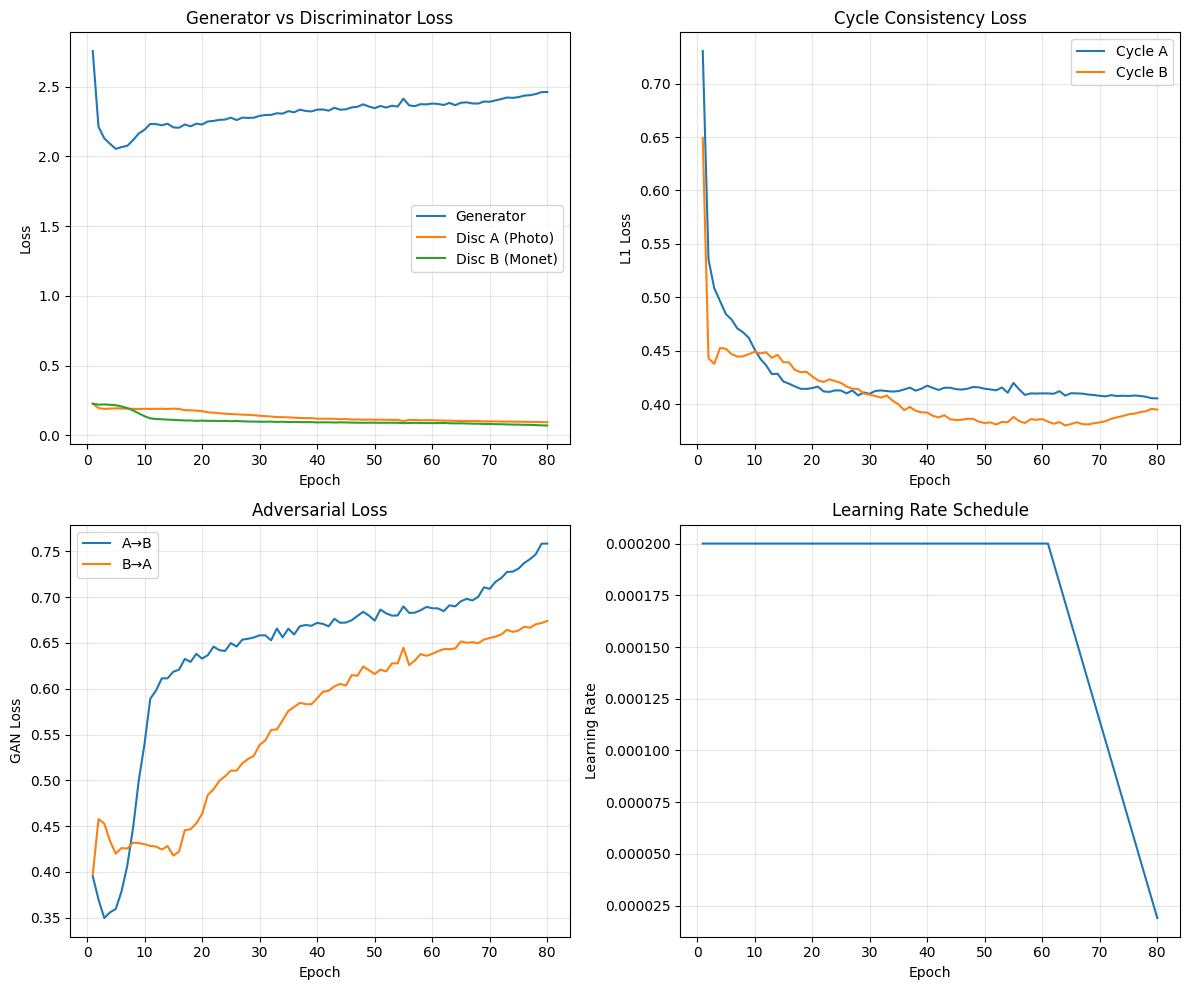

In [ ]:
# Plot training curves
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Generator vs Discriminator loss
axes[0, 0].plot(history["epoch"], history["loss_G"], label="Generator")
axes[0, 0].plot(history["epoch"], history["loss_D_A"], label="Disc A (Photo)")
axes[0, 0].plot(history["epoch"], history["loss_D_B"], label="Disc B (Monet)")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].set_title("Generator vs Discriminator Loss")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Cycle consistency loss
axes[0, 1].plot(history["epoch"], history["loss_cycle_A"], label="Cycle A")
axes[0, 1].plot(history["epoch"], history["loss_cycle_B"], label="Cycle B")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("L1 Loss")
axes[0, 1].set_title("Cycle Consistency Loss")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# GAN losses
axes[1, 0].plot(history["epoch"], history["loss_GAN_AB"], label="A→B")
axes[1, 0].plot(history["epoch"], history["loss_GAN_BA"], label="B→A")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("GAN Loss")
axes[1, 0].set_title("Adversarial Loss")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Learning rate
axes[1, 1].plot(history["epoch"], history["lr"])
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Learning Rate")
axes[1, 1].set_title("Learning Rate Schedule")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plots" / "loss_curves.png", dpi=150)
plt.show()

## Step 5 — Evaluation Metrics

In [112]:
# Load best checkpoint for evaluation
ckpt_files = sorted(CKPT_DIR.glob(f"{CFG['run']['tag']}*.pt"))
if ckpt_files:
    best_ckpt = ckpt_files[-1]  # Latest checkpoint
    ckpt = torch.load(best_ckpt, map_location=DEVICE)
    G_AB.load_state_dict(ckpt["G_AB"])
    G_BA.load_state_dict(ckpt["G_BA"])
    print(f"Loaded checkpoint: {best_ckpt}")
else:
    print("No checkpoint found, using current model state")

No checkpoint found, using current model state


In [ ]:
# Generate all translations for evaluation
G_AB.eval()
G_BA.eval()

photo_files = sorted(DOMAIN_A_DIR.glob("*.jpg"))
monet_files = sorted(DOMAIN_B_DIR.glob("*.jpg"))

print(f"Generating {len(photo_files)} photo → Monet translations...")
with torch.no_grad():
    for i, img_path in enumerate(photo_files):
        img = Image.open(img_path).convert("RGB")
        img_t = test_transform(img).unsqueeze(0).to(DEVICE)
        fake_monet = G_AB(img_t)
        # Denormalize and save
        fake_monet = (fake_monet.squeeze(0).cpu() * 0.5 + 0.5).clamp(0, 1)
        save_image(fake_monet, OUTPUT_DIR / "pred_A2B" / img_path.name)
        if (i + 1) % 1000 == 0:
            print(f"  {i+1}/{len(photo_files)}")

print(f"Generating {len(monet_files)} Monet → photo translations...")
with torch.no_grad():
    for i, img_path in enumerate(monet_files):
        img = Image.open(img_path).convert("RGB")
        img_t = test_transform(img).unsqueeze(0).to(DEVICE)
        fake_photo = G_BA(img_t)
        fake_photo = (fake_photo.squeeze(0).cpu() * 0.5 + 0.5).clamp(0, 1)
        save_image(fake_photo, OUTPUT_DIR / "pred_B2A" / img_path.name)

print("Done!")

Generating 7038 photo → Monet translations...
  1000/7038
  2000/7038
  3000/7038
  4000/7038
  5000/7038
  6000/7038
  7000/7038
Generating 300 Monet → photo translations...
Done!


In [ ]:
# Compute cycle reconstruction L1 distance
print("Computing cycle reconstruction L1...")
n_samples = CFG["eval"]["cycle_l1_samples"]

cycle_l1_A = []
cycle_l1_B = []

with torch.no_grad():
    # A -> B -> A
    for img_path in photo_files[:n_samples]:
        img = Image.open(img_path).convert("RGB")
        img_t = test_transform(img).unsqueeze(0).to(DEVICE)
        fake_B = G_AB(img_t)
        rec_A = G_BA(fake_B)
        l1 = F.l1_loss(rec_A, img_t).item()
        cycle_l1_A.append(l1)

    # B -> A -> B
    for img_path in monet_files[:n_samples]:
        img = Image.open(img_path).convert("RGB")
        img_t = test_transform(img).unsqueeze(0).to(DEVICE)
        fake_A = G_BA(img_t)
        rec_B = G_AB(fake_A)
        l1 = F.l1_loss(rec_B, img_t).item()
        cycle_l1_B.append(l1)

mean_cycle_l1_A = np.mean(cycle_l1_A)
mean_cycle_l1_B = np.mean(cycle_l1_B)
print(f"Cycle L1 (A→B→A): {mean_cycle_l1_A:.4f}")
print(f"Cycle L1 (B→A→B): {mean_cycle_l1_B:.4f}")

Computing cycle reconstruction L1...
Cycle L1 (A→B→A): 0.0419
Cycle L1 (B→A→B): 0.0437


In [ ]:
# Compute FID and KID using clean-fid
try:
    from cleanfid import fid as cleanfid

    print("Computing FID (Photo → Monet)...")
    fid_A2B = cleanfid.compute_fid(
        str(OUTPUT_DIR / "pred_A2B"),
        str(DOMAIN_B_DIR),
        mode="clean"
    )
    print(f"FID (Photo → Monet): {fid_A2B:.2f}")

    print("Computing FID (Monet → Photo)...")
    fid_B2A = cleanfid.compute_fid(
        str(OUTPUT_DIR / "pred_B2A"),
        str(DOMAIN_A_DIR),
        mode="clean"
    )
    print(f"FID (Monet → Photo): {fid_B2A:.2f}")

    print("Computing KID (Photo → Monet)...")
    kid_A2B = cleanfid.compute_kid(
        str(OUTPUT_DIR / "pred_A2B"),
        str(DOMAIN_B_DIR)
    )
    print(f"KID (Photo → Monet): {kid_A2B:.4f}")

    print("Computing KID (Monet → Photo)...")
    kid_B2A = cleanfid.compute_kid(
        str(OUTPUT_DIR / "pred_B2A"),
        str(DOMAIN_A_DIR)
    )
    print(f"KID (Monet → Photo): {kid_B2A:.4f}")

except ImportError:
    print("clean-fid not installed. Run: pip install clean-fid")
    fid_A2B = fid_B2A = kid_A2B = kid_B2A = None

Computing FID (Photo → Monet)...
compute FID between two folders
Found 7038 images in the folder /content/drive/MyDrive/DATA266_Lab1/task3_gan/shreya_akotiya/outputs/pred_A2B


FID pred_A2B : 100%|██████████| 220/220 [00:15<00:00, 13.83it/s]


Found 300 images in the folder /content/drive/MyDrive/DATA266_Lab1/task3_gan/data/monet_jpg


FID monet_jpg : 100%|██████████| 10/10 [00:03<00:00,  2.53it/s]


FID (Photo → Monet): 80.55
Computing FID (Monet → Photo)...
compute FID between two folders
Found 300 images in the folder /content/drive/MyDrive/DATA266_Lab1/task3_gan/shreya_akotiya/outputs/pred_B2A


...

KID (Photo → Monet): 0.0110
Computing KID (Monet → Photo)...
compute KID between two folders
Found 300 images in the folder /content/drive/MyDrive/DATA266_Lab1/task3_gan/shreya_akotiya/outputs/pred_B2A


KID pred_B2A : 100%|██████████| 10/10 [00:03<00:00,  2.91it/s]


Found 7038 images in the folder /content/drive/MyDrive/DATA266_Lab1/task3_gan/data/photo_jpg


KID photo_jpg : 100%|██████████| 220/220 [00:12<00:00, 17.65it/s]


KID (Monet → Photo): 0.0213


In [ ]:
# Compute LPIPS
try:
    import lpips

    lpips_net = lpips.LPIPS(net='alex').to(DEVICE)
    lpips_net.eval()

    print("Computing LPIPS (perceptual similarity)...")
    lpips_scores = []

    with torch.no_grad():
        for img_path in photo_files[:200]:  # Sample
            img = Image.open(img_path).convert("RGB")
            img_t = test_transform(img).unsqueeze(0).to(DEVICE)
            fake_B = G_AB(img_t)
            score = lpips_net(img_t, fake_B).item()
            lpips_scores.append(score)

    mean_lpips = np.mean(lpips_scores)
    print(f"LPIPS (Photo → Monet): {mean_lpips:.4f}")

except ImportError:
    print("lpips not installed. Run: pip install lpips")
    mean_lpips = None

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.13/dist-packages/lpips/weights/v0.1/alex.pth
Computing LPIPS (perceptual similarity)...
LPIPS (Photo → Monet): 0.3156


In [ ]:
# Compile metrics report
metrics = {
    "member": MEMBER,
    "run_tag": RUN_TAG,
    "model_type": "CycleGAN_UNet",
    "generator": "UNet",
    "discriminator": "PatchGAN",
    "image_size": IMG_SIZE,
    "epochs": n_epochs,
    "param_count_total": count_params(G_AB) + count_params(G_BA) + count_params(D_A) + count_params(D_B),
    "param_count_G_AB": count_params(G_AB),
    "param_count_G_BA": count_params(G_BA),
    "param_count_D_A": count_params(D_A),
    "param_count_D_B": count_params(D_B),
    "final_loss_G": history["loss_G"][-1] if history["loss_G"] else None,
    "final_loss_D_A": history["loss_D_A"][-1] if history["loss_D_A"] else None,
    "final_loss_D_B": history["loss_D_B"][-1] if history["loss_D_B"] else None,
    "final_cycle_loss_A": history["loss_cycle_A"][-1] if history["loss_cycle_A"] else None,
    "final_cycle_loss_B": history["loss_cycle_B"][-1] if history["loss_cycle_B"] else None,
    "cycle_l1_A2B2A": mean_cycle_l1_A,
    "cycle_l1_B2A2B": mean_cycle_l1_B,
    "fid_photo_to_monet": fid_A2B,
    "fid_monet_to_photo": fid_B2A,
    "kid_photo_to_monet": kid_A2B,
    "kid_monet_to_photo": kid_B2A,
    "lpips_photo_to_monet": mean_lpips,
    "training_time_hours": total_time / 3600 if 'total_time' in dir() else None,
    "device": str(DEVICE)
}

metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv(MEMBER_DIR / "full_metrics_report.csv", index=False)
print(f"Saved metrics to {MEMBER_DIR / 'full_metrics_report.csv'}")
metrics_df.T

Saved metrics to /content/drive/MyDrive/DATA266_Lab1/task3_gan/shreya_akotiya/full_metrics_report.csv


,0
member,shreya_akotiya
run_tag,t3_shreya_unet_128_20261002_023102
model_type,CycleGAN_UNet
generator,UNet
discriminator,PatchGAN
image_size,256
epochs,80
param_count_total,84967560
param_count_G_AB,41821187
param_count_G_BA,41821187


In [116]:
# ============================================================
# Compute FID and MiFID for Kaggle Submission (CORRECTED)
# ============================================================
import numpy as np
from scipy import linalg
from PIL import Image
from torchvision import transforms
from torchvision.models import inception_v3, Inception_V3_Weights
from tqdm import tqdm
import torch

# Load pretrained Inception-v3
inception = inception_v3(weights=Inception_V3_Weights.IMAGENET1K_V1)
inception.fc = torch.nn.Identity()
inception = inception.to(DEVICE)
inception.eval()

inception_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def extract_features(folder, model, max_images=None):
    files = sorted(folder.glob("*.jpg"))
    if max_images:
        files = files[:max_images]
    features = []
    with torch.no_grad():
        for img_path in tqdm(files, desc=f"Features {folder.name}"):
            img = Image.open(img_path).convert("RGB")
            img_t = inception_transform(img).unsqueeze(0).to(DEVICE)
            feat = model(img_t).cpu().numpy().flatten()
            features.append(feat)
    return np.array(features)

# Extract features
pred_dir = OUTPUT_DIR / "pred_A2B"
monet_dir = DOMAIN_B_DIR

print("Extracting generated image features...")
gen_feats = extract_features(pred_dir, inception)

print("Extracting real Monet features...")
real_feats = extract_features(monet_dir, inception)

# ============ Compute FID ============
mu_gen, sigma_gen = np.mean(gen_feats, axis=0), np.cov(gen_feats, rowvar=False)
mu_real, sigma_real = np.mean(real_feats, axis=0), np.cov(real_feats, rowvar=False)

diff = mu_gen - mu_real
covmean = linalg.sqrtm(sigma_gen @ sigma_real)
if np.iscomplexobj(covmean):
    covmean = covmean.real

fid_value = float(diff @ diff + np.trace(sigma_gen + sigma_real - 2 * covmean))

# ============ Compute MiFID ============
# Subsample to equal sizes
N = min(len(gen_feats), len(real_feats))
np.random.seed(42)
gen_idx = np.random.choice(len(gen_feats), N, replace=False)
real_idx = np.random.choice(len(real_feats), N, replace=False)

gen_subset = gen_feats[gen_idx]
real_subset = real_feats[real_idx]

# Compute cosine distance for each PAIR (i, i)
distances = []
for i in range(N):
    f_g = gen_subset[i]
    f_r = real_subset[i]
    cos_sim = np.dot(f_g, f_r) / (np.linalg.norm(f_g) * np.linalg.norm(f_r))
    d_i = 1 - cos_sim  # Cosine distance
    distances.append(d_i)

mifid_value = float(np.mean(distances))

# ============ Results ============
final_score = (fid_value + mifid_value) / 2

print(f"\n{'='*50}")
print(f"FID:         {fid_value:.4f}")
print(f"MiFID:       {mifid_value:.4f}")
print(f"Final Score: {final_score:.4f}")
print(f"{'='*50}")

# Create submission CSV
submission_df = pd.DataFrame({
    "ID": [1],
    "FID": [fid_value],
    "MiFID": [mifid_value]
})

submission_csv_path = MEMBER_DIR / "submission.csv"
submission_df.to_csv(submission_csv_path, index=False)
print(f"\nSaved: {submission_csv_path}")
print(submission_df)

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 178MB/s]


Extracting generated image features...


Features pred_A2B: 100%|██████████| 7038/7038 [02:18<00:00, 50.91it/s]


Extracting real Monet features...


Features monet_jpg: 100%|██████████| 300/300 [00:05<00:00, 52.82it/s]



FID:         79.1538
MiFID:       0.4036
Final Score: 39.7787

Saved: /content/drive/MyDrive/DATA266_Lab1/task3_gan/shreya_akotiya/submission.csv
   ID       FID     MiFID
0   1  79.15385  0.403568


In [ ]:
# Create submission zip
import zipfile

submission_dir = OUTPUT_DIR / "pred_A2B"
submission_zip = MEMBER_DIR / "images.zip"

print(f"Creating submission zip from {submission_dir}...")
with zipfile.ZipFile(submission_zip, "w", zipfile.ZIP_DEFLATED) as zf:
    for img_file in sorted(submission_dir.glob("*.jpg")):
        zf.write(img_file, img_file.name)

print(f"Created: {submission_zip}")
print(f"Size: {submission_zip.stat().st_size / 1e6:.1f} MB")
print(f"Files: {len(list(submission_dir.glob('*.jpg')))}")
print("\nUpload this zip to Kaggle: https://www.kaggle.com/c/gan-getting-started/submit")

In [ ]:
# Compute checkpoint hash
def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

ckpt_files = sorted(CKPT_DIR.glob(f"{CFG['run']['tag']}*.pt"))
ckpt_hash = sha256_file(ckpt_files[-1]) if ckpt_files else None

manifest = {
    "run_tag": RUN_TAG,
    "member": MEMBER,
    "task": "task3_gan",
    "timestamp": datetime.now().isoformat(),
    "config": CFG,
    "checkpoint": {
        "path": str(ckpt_files[-1]) if ckpt_files else None,
        "sha256": ckpt_hash
    },
    "environment": {
        "python": sys.version,
        "torch": torch.__version__,
        "device": str(DEVICE)
    },
    "metrics_summary": {
        "fid_photo_to_monet": fid_A2B,
        "fid_monet_to_photo": fid_B2A,
        "cycle_l1_A": mean_cycle_l1_A,
        "cycle_l1_B": mean_cycle_l1_B
    }
}

manifest_dir = PROJECT_ROOT / "reproducibility" / "manifests" / MEMBER
manifest_dir.mkdir(parents=True, exist_ok=True)
manifest_path = manifest_dir / f"{RUN_TAG}.json"

with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2, default=str)

print(f"Saved manifest: {manifest_path}")

Saved manifest: /content/drive/MyDrive/DATA266_Lab1/reproducibility/manifests/shreya_akotiya/t3_shreya_unet_128_20261002_023102.json
